# OTTO | Training scale and checkpoint recovery

**Alvaro Mendizabal | September 21, 2026, 8:09 PM Pacific**

This review separates model construction, evaluation completion, and an earned performance claim. It uses sanitized aggregate evidence from the latest owner-run AWS return. It does not train models or require access to private data.

**Current result:** three new rankers finished; 249 of 256 evaluation chunks are committed. The fixed worker budget paused the run with 448 sessions remaining. There is no final scale-up score or promotion decision yet.

[Delivered system](../../README.md) · [Earlier completed experiments](01_frontier_review.ipynb) · [Machine-readable snapshot](training_scale_status.json)

In [1]:
import json
from pathlib import Path
p = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "research/frontier/training_scale_status.json").exists())
s = json.loads((p / "research/frontier/training_scale_status.json").read_text())
assert s["evaluation_sessions_completed"] + s["remaining_sessions"] == s["evaluation_sessions_planned"]
assert s["new_models_completed"] == 3 and s["final_score"] is None
print(f'{s["status"]}: {s["new_models_completed"]} new models; {s["evaluation_sessions_completed"]:,}/{s["evaluation_sessions_planned"]:,} evaluation sessions.')
print("Scientific configuration is unchanged. Model improvement is not yet established.")

PAUSED_CHECKPOINTED: 3 new models; 15,936/16,384 evaluation sessions.
Scientific configuration is unchanged. Model improvement is not yet established.


## 1. Did more sessions produce useful ranking comparisons?

The training cohort grew from 8,192 to 32,768 sessions. The original 498,404 sampled rows were retained inside a total of 1,993,202 rows. Candidates, 134 features, sampling policy and model recipe were held fixed.

A query with both positive and negative candidates can supply within-session ranking comparisons. The order count increased from 685 to 2,644, passing the predefined requirement to at least double support. These counts describe training support, not generalization or business impact.

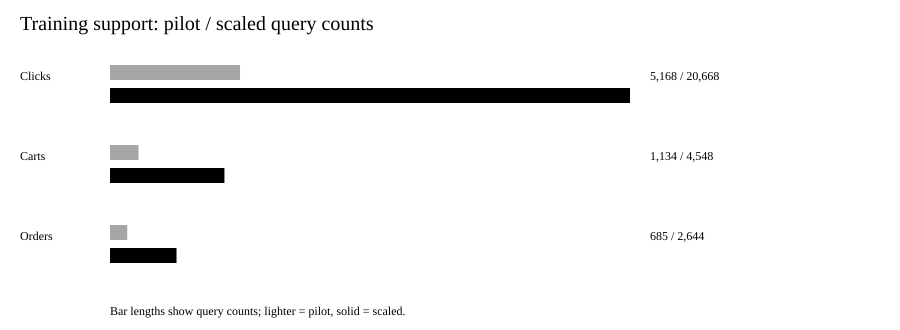

Orders: 685 -> 2,644 comparison queries. This is support growth, not recall gain.


In [2]:
import html
from matplotlib import rcParams
from matplotlib.colors import to_hex
bg = to_hex(rcParams["figure.facecolor"])
import plotly.graph_objects as go
from IPython.display import display
names = ["Clicks", "Carts", "Orders"]
a = [s["comparison_queries"]["pilot_8192"][n.lower()] for n in names]
b = [s["comparison_queries"]["scaled_32768"][n.lower()] for n in names]
f = go.Figure([go.Bar(name="8,192 training sessions", x=names, y=a), go.Bar(name="32,768 training sessions", x=names, y=b)])
f.update_layout(width=900, height=400, barmode="group", template=None, title="Training queries with positive and negative candidates", yaxis_title="Queries (count)", margin=dict(t=65,b=60))
svg = '<svg xmlns="http://www.w3.org/2000/svg" width="900" height="330" role="img"><title>Training comparison queries; not model performance</title><text x="20" y="30" font-size="20">Training support: pilot / scaled query counts</text>'
for i,(name,old,new) in enumerate(zip(names,a,b)):
    y = 65 + 80*i
    svg += f'<text x="20" y="{y+15}">{html.escape(name)}</text><rect x="110" y="{y}" width="{old/max(b)*520:.2f}" height="15" opacity="0.35"/><rect x="110" y="{y+23}" width="{new/max(b)*520:.2f}" height="15"/><text x="650" y="{y+15}">{old:,} / {new:,}</text>'
svg = svg.replace('<title>', f'<rect width="100%" height="100%" fill="{bg}"/><title>', 1)
svg += '<text x="110" y="315">Bar lengths show query counts; lighter = pilot, solid = scaled.</text></svg>'
display({"application/vnd.plotly.v1+json":f.to_plotly_json(),"image/svg+xml":svg,"text/plain":"Training comparison query counts"},raw=True)
print("Orders: 685 -> 2,644 comparison queries. This is support growth, not recall gain.")

## 2. What is complete, and what remains?

The real eight-session replay passed before fitting. All 384 additional training chunks were generated, and the three models were sealed. Evaluation then committed 249 chunks of 64 sessions each before stopping at its deadline.

The returned archive passed 922 included-file checksum checks; all 249 scoring chunks match the frozen ID order, count bounds and receipts. Model seals agree with model receipts and the omitted-artifact inventory. Actual native weights are private and were not downloaded for this review.

The saved AWS notebook has six executed code cells and three inline Plotly figures with static previews, but it is an evidence/plan notebook: `new_experiment_included` is false. It must not be represented as the completed scale-up result.

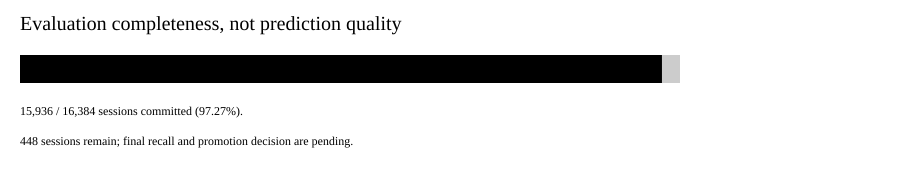

448 sessions = 7 chunks remain. Resume checkpoints, not training.


In [3]:
done, planned = s["evaluation_sessions_completed"], s["evaluation_sessions_planned"]
f = go.Figure([go.Bar(name="Committed",x=[done],y=["Evaluation sessions"],orientation="h"),go.Bar(name="Remaining",x=[planned-done],y=["Evaluation sessions"],orientation="h")])
f.update_layout(width=900,height=260,barmode="stack",template=None,title="Evaluation completeness - not prediction quality",xaxis_title="Sessions (count)",xaxis=dict(range=[0,planned]),margin=dict(t=65,l=150,b=65))
w = done/planned*660
svg = f'<svg xmlns="http://www.w3.org/2000/svg" width="900" height="180" role="img"><title>Evaluation checkpoint progress</title><text x="20" y="30" font-size="20">Evaluation completeness, not prediction quality</text><rect x="20" y="55" width="660" height="28" opacity="0.2"/><rect x="20" y="55" width="{w:.2f}" height="28"/><text x="20" y="115">15,936 / 16,384 sessions committed (97.27%).</text><text x="20" y="145">448 sessions remain; final recall and promotion decision are pending.</text></svg>'
svg = svg.replace('<title>', f'<rect width="100%" height="100%" fill="{bg}"/><title>', 1)
display({"application/vnd.plotly.v1+json":f.to_plotly_json(),"image/svg+xml":svg,"text/plain":"249 of 256 evaluation chunks complete"},raw=True)
print(f"{planned-done:,} sessions = 7 chunks remain. Resume checkpoints, not training.")

## 3. Resume the fixed experiment before deciding

The next owner-run invocation uses the identical handoff and science ID. It rechecks existing inputs, caches and model hashes, regenerates only missing evaluation chunks, then computes the full-cohort metric, paired interval and fixed decision. It may reread cached training arrays for verification; reuse does not mean skipping integrity checks.

A local synthetic interruption test stopped this same worker after one of two evaluation chunks. On resume, all three completed models and training chunks were reused, only the missing evaluation chunk was generated, and no existing binary checkpoint changed. This test verifies engineering behavior, not real-data predictive performance.

The original promotion threshold is unchanged: at least +0.003 weighted recall, nonnegative changes in both time halves, no pooled order loss, sufficient support and a positive lower paired confidence bound. Even passing would compare against the pilot, not establish superiority over the submitted 102-feature pipeline.

## Delivery boundary

The last authenticated submission history again verifies **0.56842 private / 0.56862 public**, reference **56132573**. No new file has been submitted. Full data, row-level targets, predictions, models and embeddings remain in AWS. The public artifact contains only aggregate evidence and this executed interpretation. Earlier incident evidence is preserved in the dated frontier review.

In [4]:
assert s["final_score"] is None and s["promotion_decision"] is None
assert not s["submission_produced"] and not s["kaggle_submitted"]
print("SCALE_STATUS_REVIEW_COMPLETE | 3 trained models | 448 sessions pending | no final score | no new submission")

SCALE_STATUS_REVIEW_COMPLETE | 3 trained models | 448 sessions pending | no final score | no new submission
